In [1]:
from datasets import load_from_disk
import sys
sys.path.append('../')
from eda import *

In [ ]:
get_static_feature(STATIC_FEATURE_PATH, CALENDAR_PATH, TRANSACTIONS_PATH_LIST, TARGET_PATH)
data = pd.read_parquet(STATIC_FEATURE_PATH)
data.head()

In [ ]:
calendar = load_calendar(CALENDAR_PATH)
logger.info('Add type feature in calendar')
calendar = get_datetime_feature(calendar, 'date')

transactions = load_transactions(TRANSACTIONS_PATH_LIST)

target_inn = load_target_inn(TARGET_PATH)
result = target_inn.copy()
result = result.drop(['target_inn'], axis=1)

In [3]:
payer_data = transactions[transactions['doc_payer_bank_name_flag']==1][['date', 'doc_payer_inn', 'trns_count', 'trns_amount']].copy()
payer_data = get_payer_or_payee_data(payer_data, 'doc_payer_inn', target_inn, calendar)

In [4]:
test = payer_data[['inn_id', 'trns_amount', 'trns_count']].groupby(['inn_id'], as_index=False).sum()

In [7]:
test['test'] = test['trns_amount'] / test['trns_count']
test

,inn_id,trns_amount,trns_count,test
0,inn1000051,5.121602e+07,534.0,95910.142727
1,inn1000246,2.583899e+08,1281.0,201709.523093
2,inn1000281,3.199619e+07,615.0,52026.321038
3,inn1000367,1.003027e+08,1016.0,98723.081148
4,inn1000409,2.068075e+07,679.0,30457.663555
...,...,...,...,...
51958,inn999585,6.745448e+08,1878.0,359182.526524
51959,inn999624,2.641407e+07,1267.0,20847.729998
51960,inn999737,2.152160e+08,967.0,222560.485371
51961,inn999759,1.061197e+09,9886.0,107343.411656


In [ ]:
get_cat_feature(TARGET_PATH, PROFILES_PATH, CAT_FEATURE_PATH, TRANSACTIONS_PATH_LIST)
data = pd.read_parquet(CAT_FEATURE_PATH)
data.head()

In [ ]:
for column in data.columns:
    print(column, len(data[column].value_counts()))

inn_id 51963
ipul 3
id_region 86
main_okved_group 87
trns_class_encoded_payer 28
trns_class_encoded_payee 30


In [ ]:
get_dynamic_feature_day(DYNAMIC_FEATURE_DAY_PATH, CALENDAR_PATH, TRANSACTIONS_PATH_LIST, TARGET_PATH)
data = pd.read_parquet(DYNAMIC_FEATURE_DAY_PATH)
data.head()

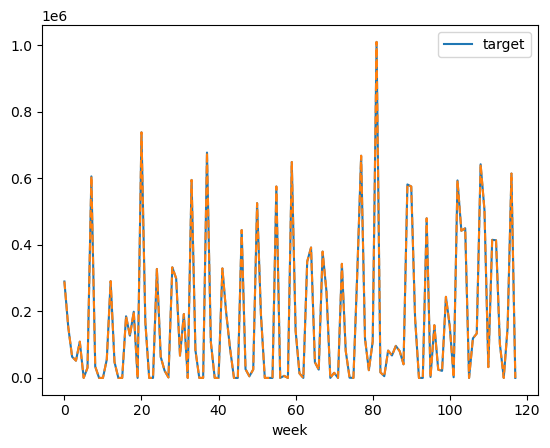

In [15]:
plot_sum_payer_and_target(DYNAMIC_FEATURE_DAY_PATH, TARGET_PATH, inn_id='inn1000409')

In [2]:
save_dataset_day(DATASET_DAY_PATH, DYNAMIC_FEATURE_DAY_PATH, STATIC_FEATURE_PATH, CAT_FEATURE_PATH)

2025-03-18,00:31:36 Load dynamic feature /mnt/data/ods/example/../data/dynamic_feature_day.parquet
2025-03-18,00:32:50 Load static data /mnt/data/ods/example/../data/static_feature.parquet
2025-03-18,00:33:11 Get train dataset
2025-03-18,00:35:23 Get val dataset
2025-03-18,00:37:27 Get predict dataset
2025-03-18,00:39:42 Save dataset /mnt/data/ods/example/../data/dataset_day


Saving the dataset (0/5 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

Saving the dataset (0/7 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

In [3]:
dataset = load_from_disk(str(DATASET_DAY_PATH))
dataset

DatasetDict({
    train: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
    val: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
    predict: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
})

In [4]:
len(dataset['train'][0]['target']), len(dataset['train'][0]['feat_dynamic_real']), len(dataset['train'][0]['feat_static_real']), len(dataset['train'][0]['feat_static_cat'])

(742, 27, 224, 5)

In [6]:
len(dataset['train'][0]['target']) / 7, len(dataset['val'][0]['target']) / 7, len(dataset['predict'][0]['target']) / 7

(106.0, 118.0, 130.0)

<Axes: >

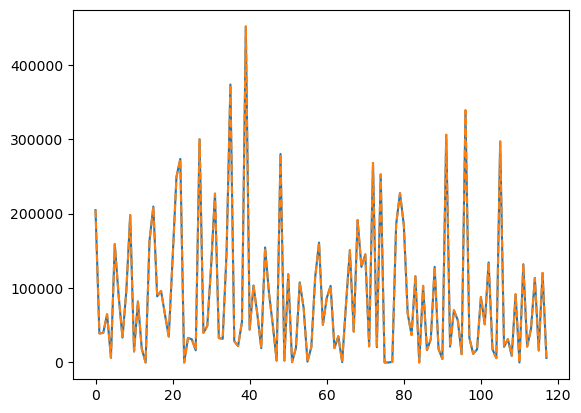

In [14]:
import numpy as np
target = pd.read_parquet(TARGET_PATH)
target = target[target.inn_id==dataset['val'][323]['inn_id']]
target.reset_index(drop=True, inplace=True)
target['target2'] = np.expm1(np.array(dataset['val'][323]['target'])).reshape((118, -1)).sum(axis=1)
target['target2'].plot()
target['target'].plot(linestyle='dashed')
